# Libraries

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Add benchmarking dir so helpers.plot is importable
_bench = Path.cwd().parents[3]
sys.path.insert(0, str(_bench))
from helpers.plot import (
    plot_grouped_bar_by_columns,
    plot_single_bar_metric,
    plot_rank_comparison,
    plot_multi_rank_comparison,
    render_dlq_analysis,
)


# Evaluating INQUIRE Benchmarks 

Here we will evaluate the raw query metrics returned by INQUIRE_benchmark. These raw metrics were calculated using [INQUIRE-Benchmark-small](https://huggingface.co/datasets/sagecontinuum/INQUIRE-Benchmark-small) with a [CLIP](https://huggingface.co/apple/DFN5B-CLIP-ViT-H-14-378) variation named `DFN5B-CLIP-ViT-H-14-378` trained on a dataset filtered by a [Data Filtering Network (DFN)](https://arxiv.org/abs/2309.17425), [NRP's](https://nrp.ai/documentation/userdocs/ai/llm-managed/#available-models) [gemma-4-31B-it](https://huggingface.co/google/gemma-4-31B-it) caption model, and set to **response_limit=50**. This means it will return up to 50 images. This was configured this way because INQUIRE uses the top 50 as well to benchmark models.

To better understand the results, each image is matched with a query in the dataset. Although not all matched images are relevant to the query.
>NOTE: INQUIRE also provides a [leaderboard](https://inquire-benchmark.github.io/). This is helpful for comparing our results.

This version is **query-only** on the v15 collections (`SKIP_INDEX=true`, **no recaption**). It tested the image search with `DFN5B-CLIP-ViT-H-14-378` and `NRP's gemma-4-31B-it` on **Milvus** (replacing Weaviate), using dual dense indexes plus BM25 and CLIP rerank. It included:

- **gemma-4-31B-it for Caption Generation**: Captions are generated for images using NRP's gemma-4-31B-it model.
- **Dual-index Vector Search**: Image and caption CLIP embeddings are stored as separate Milvus fields (`image_vector`, `caption_vector`) instead of a single fused vector. At query time, dense similarity blends both legs with `clip_alpha` (default 0.7 → 70% image / 30% caption).
- **Keyword Search (BM25)**: Milvus BM25 over `search_text` (captions and related text), replacing Weaviate keyword search.
- **Hybrid Search**: Dense (dual CLIP) + sparse (BM25) retrieval via Milvus `WeightedRanker`, controlled by `query_alpha` (default 0.65 → 65% dense / 35% keyword; effective WeightedRanker **46% image / 20% caption / 35% BM25**). Query method: `clip_hybrid_query_dual_index`.
- **CLIP Reranker (`DFN5B-CLIP-ViT-H-14-378`)**: Replaces the previous Weaviate / [ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) reranker. The query text is embedded once and scored against stored `image_vector`s (no per-hit image I/O), matching production `logits_per_image`-style ranking.
- **Triton Dynamic Batching**: CLIP (and Gemma when served on Triton) use server-side dynamic batching so concurrent embedding/caption requests are coalesced into larger GPU batches, improving indexing and query throughput versus one-request-per-inference.
- **LLM Image Byte Limiting**: Caption images are preprocessed with `LLM_IMAGE_BYTE_LIMITING=true` before NRP gemma calls: RGB conversion, longest-side cap (`LLM_MAX_IMAGE_SIDE=6144`), and JPEG downscale/quality stepping to stay under `LLM_MAX_IMAGE_BYTES` (12 MiB).
- **Two-caption prompt (`scientific_two_captions_v1`)**: Caption generation uses the shared [`prompts/`](../../../../../prompts/) catalog (`CAPTION_PROMPT_ID=scientific_two_captions_v1`). Gemma returns three fields: `long_caption` (full detail), `short_caption` (one dense visual sentence, ≤55 tokens, no device IDs/timestamps), and 15 `keywords`. The older versions used CAPTION_PROMPT_ID=scientific_detailed_v1 which utilized only long_caption.
- **CLIP text vs BM25 text split**: CLIP's 77-token limit previously truncated the full caption+keywords string (~40% embedded; keywords never reached `caption_vector`). v15 embeds **`short_caption` + `keywords`** for `caption_vector` in a single CLIP pass, while BM25 `search_text` still indexes **`long_caption` + keywords** (no detail lost on the keyword leg).
- **Milvus caption fields**: `long_caption` and `short_caption` are stored as separate VARCHAR fields (replacing a single `caption` column).
- **Query-only (`SKIP_INDEX=true`)**: Reuses the **v15 Milvus collections**. No recaption and no collection drop. v16 only changes hybrid blend weights at query time. The A–H skip-index sweep is archived in `results/v16/v16_qa*`; this notebook plots production pick **H**.

Here were the Hyperparameters used for the image search:


In [2]:
#show config values
df = pd.read_csv('config_values.csv')
df

,Config Variable,Value,Type
0,advanced_query_parameters,"{'query_alpha': 0.65, 'clip_alpha': 0.7, 'enab...",dict
1,caption_model_name,gemma,str
2,caption_model_prompt,role:\nYou are a world-class Scientific Image ...,str
3,embed_caption,True,bool
4,embed_image,True,bool
5,enable_bm25,True,bool
6,enable_caption_generation,True,bool
7,hnsw_dist_metric,VectorDistances.COSINE,VectorDistances
8,hnsw_dynamicEfMax,500,int
9,hnsw_dynamicEfMin,200,int


## Query and Image Collection Process

This explanation was grabbed from the [INQUIRE paper](https://arxiv.org/abs/2411.02537) so that we can better understand the results in further sections

### Query Collection
To ensure that INQUIRE comprises text queries that are relevant to scientists,
we conducted interviews with individuals across different ecological and environmental domains -
including experts in ornithology, marine biology, entomology, and forestry. Further queries were
sourced from reviews of academic literature in ecology. We retained only queries that (1) could be discerned from images
alone, (2) were feasible to comprehensively label over the entire iNat24 dataset, and (3) were of
interest to domain experts.

### Image Annotation
All image annotations were performed by a small set of individuals whose
interest and familiarity with wildlife image collections enabled them to provide accurate labels for
challenging queries. Annotators were instructed to label all candidate images as either relevant (i.e.,
positive match) or not relevant (i.e., negative match) to a query, and to mark an image as not relevant
if there was reasonable doubt. To allow for comprehensive labeling, where applicable, iNat24 species
labels were used to narrow down the search to a sufficiently small size to label all relevant images for
the query of interest. For queries in which species labels could not be used, labeling was performed
over the top CLIP ViT-H-14 retrievals alone. In this case, the resulting annotations were only
kept if we were certain that this labeling captured the vast majority of positives, including labeling
until at least 100 consecutive retrievals were not relevant. Queries that were deemed
too easy, not comprehensively labeled, or otherwise not possible to label were excluded from our
benchmark. In total, this process resulted in 250 queries which involved labeling 194,334 images, of
which 32,696 were relevant to their query.

### Query Categories
Each query belongs to one of four supercategories (appearance, behavior,
context, or species), and further into one of sixteen fine-grained categories (e.g., Animal Structures
and Habitats). We also note
queries that use scientific terminology, words typically used only within scientific contexts (e.g., “A
godwit performing distal rhynchokinesis”).

### Data Split
We divide all queries into 50 validation and 200 test queries using a random split,
stratified by category.

## Query Coverage

Queries cover a range of topics and a organism taxonomies:

![Query Coverage](https://github.com/waggle-sensor/sage-vectordb-example/blob/main/INQUIRE_benchmark/results/images/inquire_iconic_groups.png?raw=1)
![Query Coverage](https://github.com/waggle-sensor/sage-vectordb-example/blob/main/INQUIRE_benchmark/results/images/inquire_categories.png?raw=1)

## Query Metric Dataset

Each row in the dataframe is evaluating a query used in our image search system:
- **query_id**: an ID given to each unique query in the dataset
- **query**: The query inserted into our image search. These are the same queries created by the INQUIRE authors.
- **total_images**: The total images returned from our image search using the specified query.
- **correctly_returned**: The number of images returned that matched with the query indicated in the dataset. For example, if the query was "apple" for the image in the dataset and I used the query "apple" in our image search system. The image returned would be marked as correctly returned since the queries matched.
- **incorrectly_returned**: The number of images returned that did NOT match with the query in the dataset. Using the example above, if we used the query "banana" in our image search system and the image retured had a query of "apple" in the dataset then this will be marked as incorreclt returned.
- **relevant_images**: The number of images returned marked as relevant. Each image in the dataset is marked as relevant or nonrelavent to the query it is matched with.
- **non_relevant_images**: The number of images returned marked as nonrelevant. Each image in the dataset is marked as relevant or nonrelavent to the query it is matched with.
- **accuracy**: The number of images correctly returned compared to the total images.
- **precision**: The number of relevant images returned compared to the total images.
- **recall**: The number of relevant images returned compared to the number of relevant images in the dataset.
- **hit**: Measures whether at least one relevant result appears in the results. To get hit rate we take the mean of the hit column.
- **diversity**: The diversity of the returned images. Measures how diverse (non-redundant) the top-k list is based on the cosine similarity of the retrieved item vectors. ILS (Intra-List Similarity) is the average pairwise cosine similarity of the retrieved item vectors; diversity = 1 − ILS, so a higher diversity score is more diverse.
- **NDCG**: A metric used to evaluate a rerank model. A higher score means relevant images were given a higher score than nonrelevant images.
- **clip_NDCG**: NDCG was also calculated for the clip scores given in the dataset. This column can be used as a comparison to the column NDCG. CLIP ViT-H-14 was used by the INQUIRE authors to provide a rerank score for each image. If NDCG is higher than this column, that means our image search system is doing better.
- **rerank_score_reciprocal_rank**: The reciprocal rank of the rerank scores. To get MRR we take the mean of the reciprocal rank column. MRR measures how early the first relevant result appears based on rerank_score column.
- **clip_score_reciprocal_rank**: The reciprocal rank of the clip scores. To get MRR we take the mean of the reciprocal rank column. MRR measures how early the first relevant result appears based on clip_score column.
- **category**: The category given to the query by the INQUIRE authors. (ex; Defensive and Survival Behaviors)
- **supercategory**: The supercategory given the the query by the INQUIRE authors. (ex; Behavior)
- **iconic_group**: The iconic group given to the query by the INQUIRE authors. (ex; Mammals)

NOTE: k=response_limit


In [3]:
#load in metric data
df = pd.read_csv('query_eval_metrics.csv')

#rename ndcg colums
df = df.rename(columns={
    'rerank_score_NDCG': 'NDCG', 
    'clip_score_NDCG': 'clip_NDCG',
    'rerank_score_reciprocal_rank': 'rr',
    'clip_score_reciprocal_rank': 'clip_rr'
})
df

,query_id,query,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit,diversity,NDCG,clip_NDCG,rr,clip_rr,category,supercategory,iconic_group
0,83,Tagged swan,50,49,1,23,27,0.98,0.46,0.766667,1,0.235236,0.995262,0.996079,1.000000,1.000000,Tracking and Identification,Appearance,Birds
1,142,cross orbweaver,50,32,18,2,48,0.64,0.04,0.222222,1,0.340365,0.434974,0.715992,0.111111,1.000000,Species ID,Species,Arachnids
2,189,puffins carrying food,50,41,9,6,44,0.82,0.12,0.750000,1,0.284059,0.552141,0.896790,0.250000,1.000000,Feeding and Hydration,Behavior,Birds
3,6,A female pheasant,50,36,14,22,28,0.72,0.44,0.536585,1,0.309047,0.923339,0.846643,1.000000,1.000000,Sex identification,Appearance,Birds
4,98,a hermit crab using plastic waste as a shell,50,43,7,3,47,0.86,0.06,1.000000,1,0.262948,0.741038,0.529056,1.000000,0.500000,Human Impact,Context,Animalia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
155,152,feral cat with prey,50,46,4,13,37,0.92,0.26,0.928571,1,0.325749,0.863364,0.857186,1.000000,1.000000,Feeding and Hydration,Behavior,Mammals
156,47,Haliaeetus eagles in aerial cartwheeling fligh...,50,38,12,1,49,0.76,0.02,1.000000,1,0.231366,0.251940,0.354897,0.047619,0.200000,"Mating, Courtship, Reproduction",Behavior,Birds
157,43,Fur seal mother with pup,50,50,0,20,30,1.00,0.40,0.689655,1,0.192265,0.937248,0.921827,1.000000,1.000000,Cooperative and Social Behaviors,Behavior,Mammals
158,0,A By-the-Wind Sailor washed up on a beach,50,23,27,0,50,0.46,0.00,0.000000,0,0.309045,0.323698,0.687535,0.038462,1.000000,Health and Disease,Appearance,Animalia


## Indexing DLQ Summary

First, we will look at the DLQ to get an understanding of failed items.

During indexing, failed items are held in a dead-letter queue (`dlq_records.csv`), retried with exponential backoff, then recorded with a terminal status.

CSV columns: `image_id`, `query_id`, `reason`, `error`, `attempts`, `final_status`, `last_error`.

| `final_status` | Meaning |
|----------------|---------|
| `retried_ok` | A later retry succeeded with a real LLM caption |
| `inserted_degraded` | Soft caption failure exhausted retries; item was **force-inserted** using the dataset `summary` as caption backup (or `""` if none) |
| `abandoned` | Hard failure (or force-insert failed); item was **not** indexed |

`reason` is typically `caption_failed` (empty LLM caption) or `hard_fail` (CLIP / processing errors). Use the tables below to see how often fallback was used versus full abandon.

In [4]:
render_dlq_analysis(Path("."))


DLQ rows: 0  |  unique image_ids: 0 | unique query_ids: 0
Nothing to summarize.


## Overall Metrics
Now, we will begin with evaluating all queries.

In [5]:
#calculate the average/sum of each metric
total_images = df['total_images'].sum()
correctly_returned = df['correctly_returned'].sum()
incorrectly_returned = df['incorrectly_returned'].sum()
relevant_images = df['relevant_images'].sum()
non_relevant_images = df['non_relevant_images'].sum()
accuracy = df['accuracy'].mean()
precision = df['precision'].mean()
recall = df['recall'].mean()
hit_rate = df['hit'].mean()
ndcg = df['NDCG'].mean()
clip_ndcg = df['clip_NDCG'].mean()
mrr = df['rr'].mean()
clip_mrr = df['clip_rr'].mean()
diversity = df['diversity'].mean()


# Summary of key metrics
overall_metrics = {
    'total_images': total_images,
    'correctly_returned': correctly_returned,
    'incorrectly_returned': incorrectly_returned,
    'relevant_images': relevant_images,
    'non_relevant_images': non_relevant_images,
    'accuracy': accuracy,
    'precision': precision,
    'recall': recall,
    'hit_rate': hit_rate,
    'NDCG': ndcg,
    'clip_NDCG': clip_ndcg,
    'mrr': mrr,
    'clip_mrr': clip_mrr,
    'diversity': diversity
}

# Print the summary
for key, value in overall_metrics.items():
    print(f"{key}: {value}")

# Insights
print("\nInsights:")
print(f"The system returned a total of {correctly_returned} correct images out of {total_images} total images returned.")
print(f"The accuracy of the system is {accuracy:.4f}, indicating that {accuracy*100:.2f}% of the returned images correctly matched with the query.")
print(f"The precision of the system is {precision:.4f}, indicating that {precision*100:.2f}% of the total images returned were relevant images.")
print(f"The recall of the system is {recall:.4f}, indicating that {recall*100:.2f}% of the total relevant images in the dataset were returned.")
print(f"The hit rate of the system is {hit_rate:.4f}, indicating that {hit_rate*100:.2f}% of the total queries processed had at least one relevant image.")
print(f"The NDCG score is {ndcg:.4f}, and the Clip NDCG score is {clip_ndcg:.4f}, indicating the ranking quality of the returned images against the base CLIP ViT-H-14 the INQUIRE authors used.")
print(f"The MRR score is {mrr:.4f}, and the Clip MRR score is {clip_mrr:.4f}, indicating the ranking quality of the returned images against the base CLIP ViT-H-14 the INQUIRE authors used.")
print(f"The diversity of the system is {diversity:.4f} (on a 0–1 scale), indicating the \"spread\" of the returned images. A lower score means the results are more redundant (i.e., highly similar to each other), while a higher score indicates more varied results.")


total_images: 8000
correctly_returned: 6018
incorrectly_returned: 1982
relevant_images: 1754
non_relevant_images: 6246
accuracy: 0.7522500000000001
precision: 0.21925000000000003
recall: 0.6041655768116098
hit_rate: 0.94375
NDCG: 0.702510510686215
clip_NDCG: 0.7198992454895508
mrr: 0.6642192527510531
clip_mrr: 0.6900798199704856
diversity: 0.24474518988732052

Insights:
The system returned a total of 6018 correct images out of 8000 total images returned.
The accuracy of the system is 0.7523, indicating that 75.23% of the returned images correctly matched with the query.
The precision of the system is 0.2193, indicating that 21.93% of the total images returned were relevant images.
The recall of the system is 0.6042, indicating that 60.42% of the total relevant images in the dataset were returned.
The hit rate of the system is 0.9437, indicating that 94.38% of the total queries processed had at least one relevant image.
The NDCG score is 0.7025, and the Clip NDCG score is 0.7199, indica

## Metrics based on Supercategory

Now, we will evaluate queries based on their categories.


In [6]:
# Group by category and calculate the sum/mean of each metric
supercategory_metrics = df.groupby('supercategory').agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

supercategory_metrics

,supercategory,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit,NDCG,clip_NDCG,rr,clip_rr,diversity
0,Appearance,2600,1750,850,448,2152,0.673077,0.172308,0.505228,0.884615,0.639843,0.690781,0.552276,0.670219,0.255582
1,Behavior,2950,2405,545,712,2238,0.815254,0.241356,0.712164,1.000000,0.750965,0.763772,0.747764,0.736975,0.229261
2,Context,2150,1614,536,520,1630,0.750698,0.241860,0.598867,0.930233,0.719138,0.707458,0.708780,0.670732,0.257034
3,Species,300,249,51,74,226,0.830000,0.246667,0.437616,1.000000,0.649999,0.629998,0.493519,0.539735,0.215019


### Accuracy

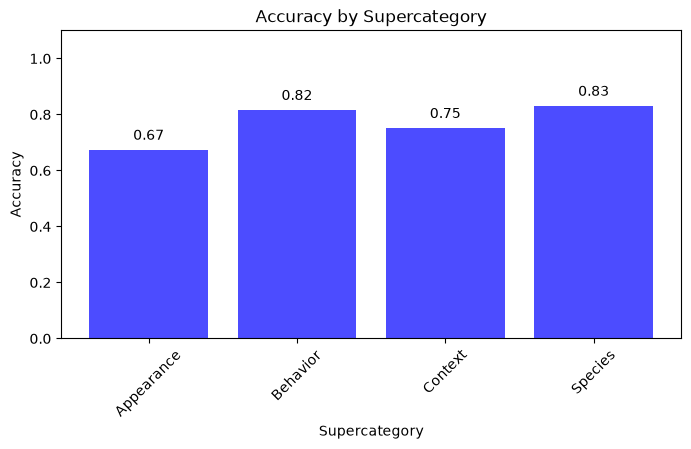

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(supercategory_metrics['supercategory'], supercategory_metrics['accuracy'], color="blue", alpha=0.7)

ax.set_ylabel("Accuracy")
ax.set_xlabel("Supercategory")
ax.set_title("Accuracy by Supercategory")
ax.set_ylim(0, 1.1)  # Accuracy is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Precision

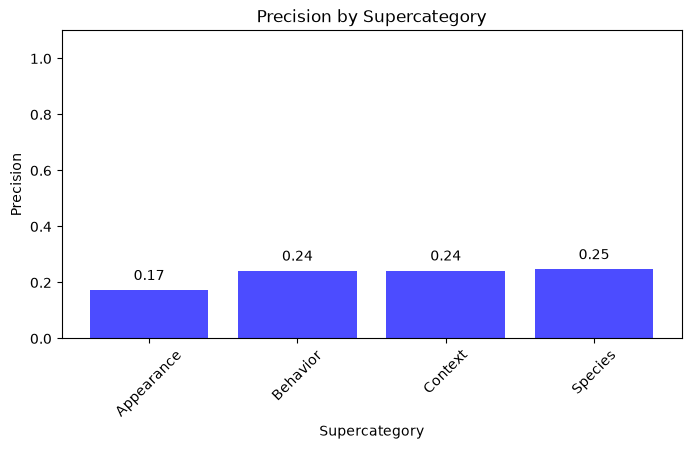

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(supercategory_metrics['supercategory'], supercategory_metrics['precision'], color="blue", alpha=0.7)

ax.set_ylabel("Precision")
ax.set_xlabel("Supercategory")
ax.set_title("Precision by Supercategory")
ax.set_ylim(0, 1.1)  # Precision is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Recall

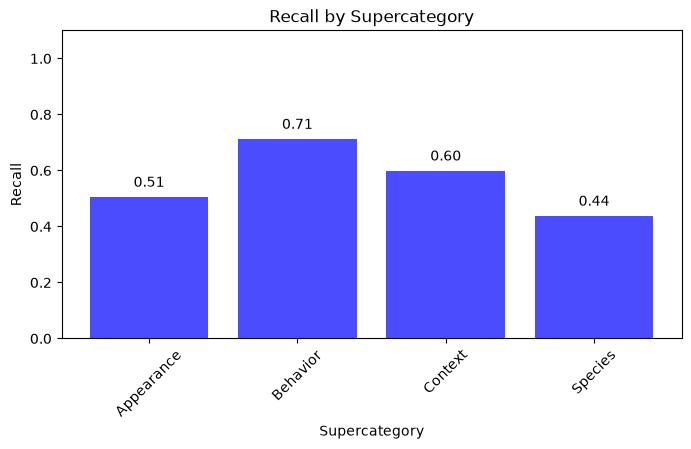

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(supercategory_metrics['supercategory'], supercategory_metrics['recall'], color="blue", alpha=0.7)

ax.set_ylabel("Recall")
ax.set_xlabel("Supercategory")
ax.set_title("Recall by Supercategory")
ax.set_ylim(0, 1.1)  # recall is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Hit Rate

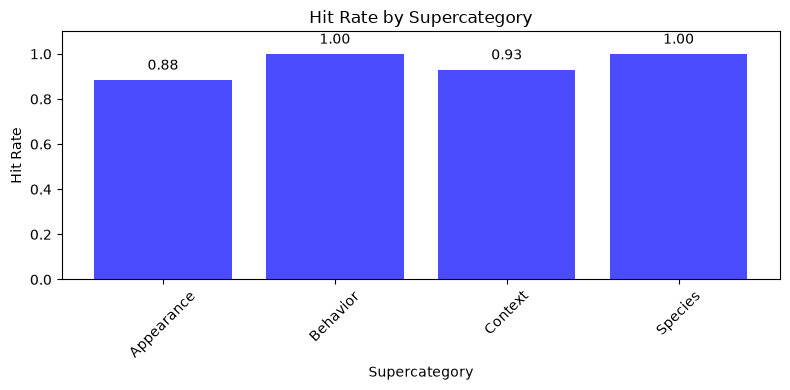

In [10]:
# Hit Rate by Supercategory
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(supercategory_metrics['supercategory'], supercategory_metrics['hit'], color="blue", alpha=0.7)
ax.set_ylabel("Hit Rate")
ax.set_xlabel("Supercategory")
ax.set_title("Hit Rate by Supercategory")
ax.set_ylim(0, 1.1)
ax.bar_label(bars, fmt="%.2f", padding=5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Diversity


Text(0.5, 1.0, 'Diversity by Supercategory')

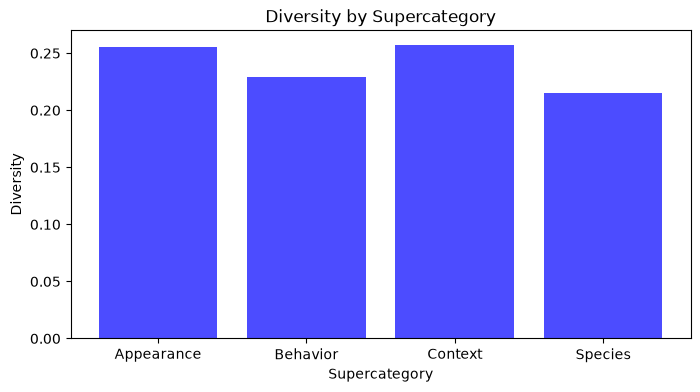

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(supercategory_metrics['supercategory'], supercategory_metrics['diversity'], color="blue", alpha=0.7)

ax.set_ylabel("Diversity")
ax.set_xlabel("Supercategory")
ax.set_title("Diversity by Supercategory")

### NDCG

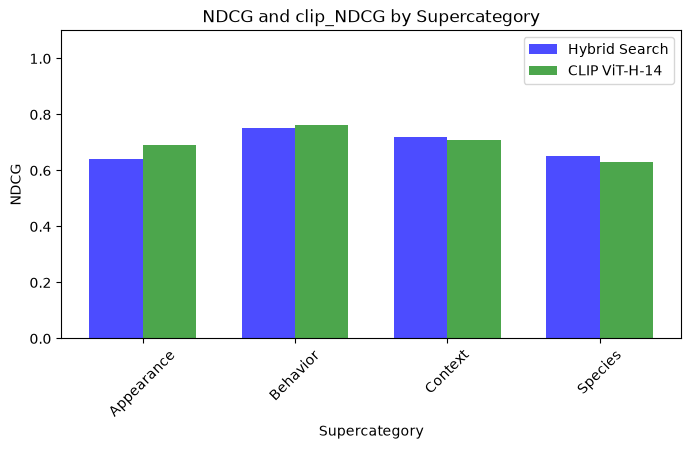

In [12]:
# Creating the plot with both NDCG and clip_NDCG
fig, ax = plt.subplots(figsize=(8, 4))

# Bar width
bar_width = 0.35
x = np.arange(len(supercategory_metrics['supercategory']))

# Bars for NDCG and clip_NDCG
bars1 = ax.bar(x - bar_width/2, supercategory_metrics['NDCG'], width=bar_width, label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, supercategory_metrics['clip_NDCG'], width=bar_width, label="CLIP ViT-H-14", color="green", alpha=0.7)

# Labels and title
ax.set_ylabel("NDCG")
ax.set_xlabel("Supercategory")
ax.set_title("NDCG and clip_NDCG by Supercategory")
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(supercategory_metrics['supercategory'], rotation=45)
ax.legend()

# Show plot
plt.show()

### MRR

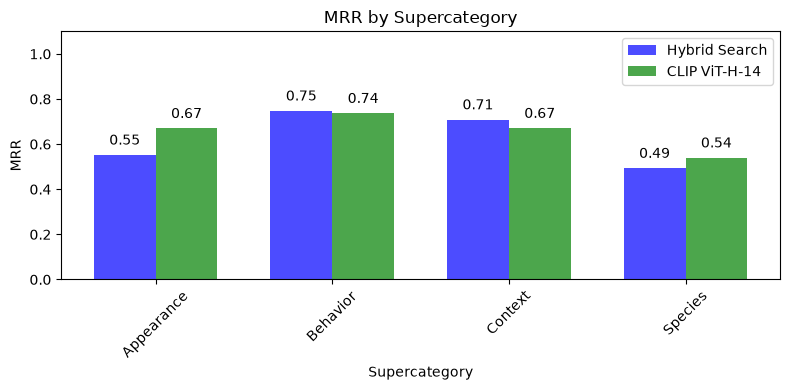

In [13]:
# MRR and clip_MRR by Supercategory
fig, ax = plt.subplots(figsize=(8, 4))
bar_width = 0.35
x = np.arange(len(supercategory_metrics['supercategory']))
bars1 = ax.bar(x - bar_width/2, supercategory_metrics['rr'], width=bar_width, label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, supercategory_metrics['clip_rr'], width=bar_width, label="CLIP ViT-H-14", color="green", alpha=0.7)
ax.set_ylabel("MRR")
ax.set_xlabel("Supercategory")
ax.set_title("MRR by Supercategory")
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(supercategory_metrics['supercategory'], rotation=45)
ax.legend()
ax.bar_label(bars1, fmt="%.2f", padding=5)
ax.bar_label(bars2, fmt="%.2f", padding=5)
plt.tight_layout()
plt.show()

## Metrics based on Category

In [14]:
# Group by category and calculate the sum/mean of each metric while keeping supercategory
category_metrics = df.groupby(['category']).agg({
    'supercategory': 'first',  # Assuming each category has a single supercategory
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).sort_values(by="supercategory").reset_index()

category_metrics

,category,supercategory,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit,NDCG,clip_NDCG,rr,clip_rr,diversity
0,Health and Disease,Appearance,600,438,162,133,467,0.730000,0.221667,0.481565,0.833333,0.643250,0.723610,0.522233,0.746111,0.234493
1,Life Cycle and Development,Appearance,750,400,350,73,677,0.533333,0.097333,0.333685,0.866667,0.541279,0.595752,0.414500,0.566449,0.280965
2,Sex identification,Appearance,400,325,75,83,317,0.812500,0.207500,0.547620,1.000000,0.651782,0.665890,0.550210,0.726190,0.245442
3,Tracking and Identification,Appearance,400,279,121,97,303,0.697500,0.242500,0.652926,1.000000,0.821171,0.936999,0.916667,1.000000,0.256241
4,Unique appearances or morphs,Appearance,450,308,142,62,388,0.684444,0.137778,0.653711,0.777778,0.627781,0.608657,0.499895,0.399087,0.249824
5,Cooperative and Social Behaviors,Behavior,900,774,126,257,643,0.860000,0.285556,0.704986,1.000000,0.803113,0.800656,0.817276,0.793519,0.210946
6,Defensive and Survival Behaviors,Behavior,400,315,85,94,306,0.787500,0.235000,0.655985,1.000000,0.752901,0.801226,0.775000,0.791667,0.250876
7,Feeding and Hydration,Behavior,850,665,185,120,730,0.782353,0.141176,0.742604,1.000000,0.665056,0.693262,0.658891,0.660024,0.252375
8,"Mating, Courtship, Reproduction",Behavior,550,454,96,140,410,0.825455,0.254545,0.760138,1.000000,0.745002,0.762241,0.727814,0.730303,0.210194
9,Miscellaneous Behavior,Behavior,250,197,53,101,149,0.788000,0.404000,0.618850,1.000000,0.865346,0.814164,0.800000,0.722222,0.223968


In [15]:
# Define colors for each supercategory
supercategory_colors = {
    "Context": "red",
    "Behavior": "green",
    "Appearance": "blue",
    "Species": "orange"
}

# Assign colors based on supercategory
colors = [supercategory_colors[sc] for sc in category_metrics['supercategory']]

# Bar width
bar_width = 0.35
x = np.arange(len(category_metrics['category']))

### Accuracy

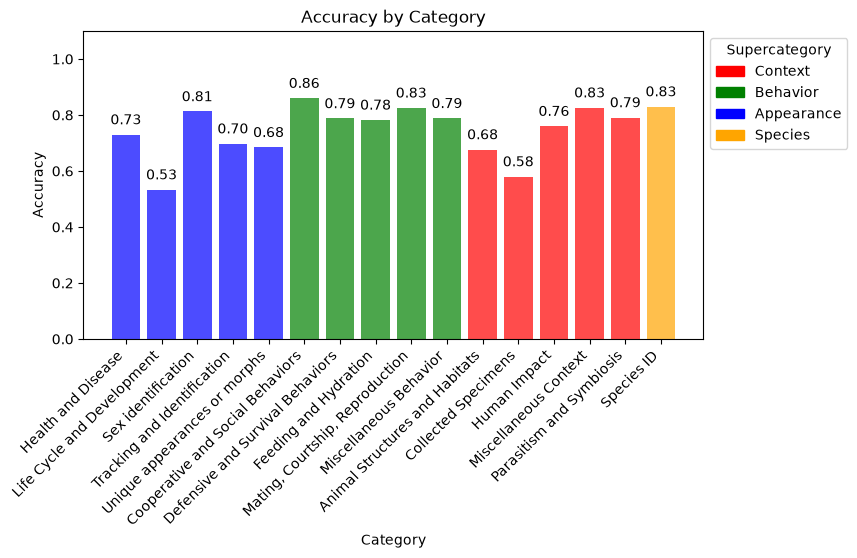

In [16]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Create bars with colors based on supercategory
bars = ax.bar(x, category_metrics['accuracy'], color=colors, alpha=0.7)

ax.set_ylabel("Accuracy")
ax.set_xlabel("Category")
ax.set_title("Accuracy by Category")
ax.set_ylim(0, 1.1)  # Extend limit to prevent overlap with title

# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

# Add legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in supercategory_colors.values()]
ax.legend(handles, supercategory_colors.keys(), title="Supercategory", loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

### Precision

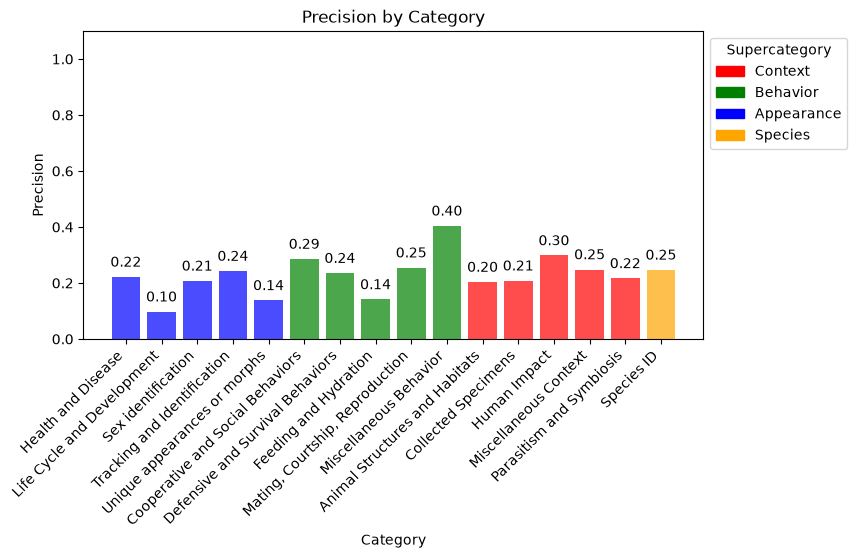

In [17]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Create bars with colors based on supercategory
bars = ax.bar(x, category_metrics['precision'], color=colors, alpha=0.7)

ax.set_ylabel("Precision")
ax.set_xlabel("Category")
ax.set_title("Precision by Category")
ax.set_ylim(0, 1.1)  # Extend limit to prevent overlap with title

# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

# Add legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in supercategory_colors.values()]
ax.legend(handles, supercategory_colors.keys(), title="Supercategory", loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

### Recall

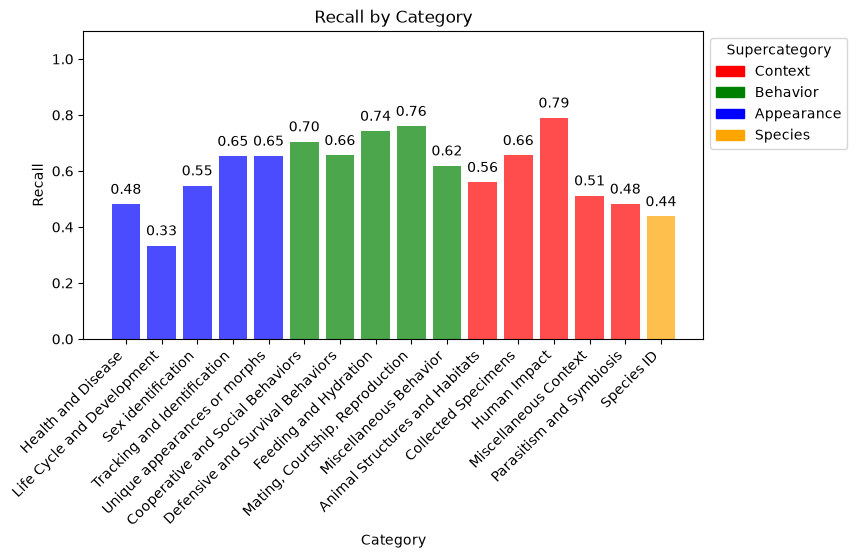

In [18]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Create bars with colors based on supercategory
bars = ax.bar(x, category_metrics['recall'], color=colors, alpha=0.7)

ax.set_ylabel("Recall")
ax.set_xlabel("Category")
ax.set_title("Recall by Category")
ax.set_ylim(0, 1.1)  # Extend limit to prevent overlap with title

# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

# Add legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in supercategory_colors.values()]
ax.legend(handles, supercategory_colors.keys(), title="Supercategory", loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

### Hit Rate

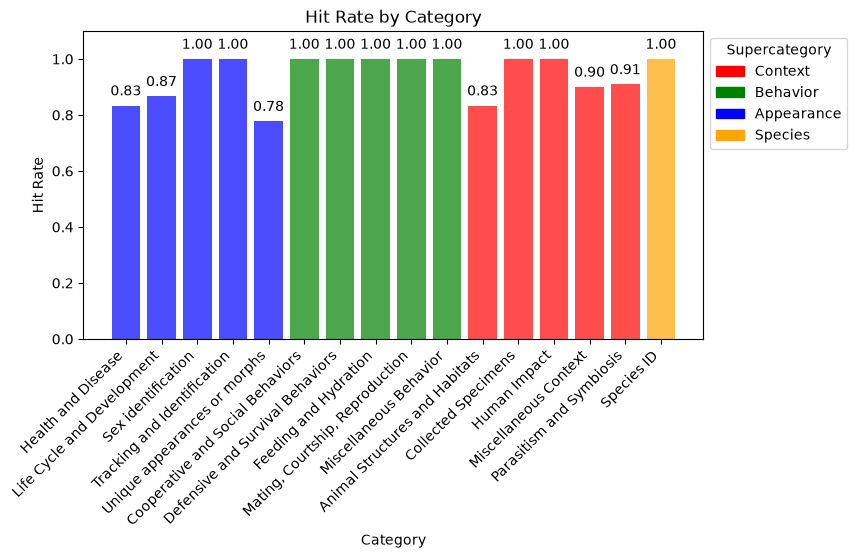

In [19]:
# Hit Rate by Category
fig, ax = plt.subplots(figsize=(8, 4))

# Create bars with colors based on supercategory
bars = ax.bar(x, category_metrics['hit'], color=colors, alpha=0.7)

ax.set_ylabel("Hit Rate")
ax.set_xlabel("Category")
ax.set_title("Hit Rate by Category")
ax.set_ylim(0, 1.1)  # Extend limit to prevent overlap with title

# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

# Add legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in supercategory_colors.values()]
ax.legend(handles, supercategory_colors.keys(), title="Supercategory", loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

### Diversity

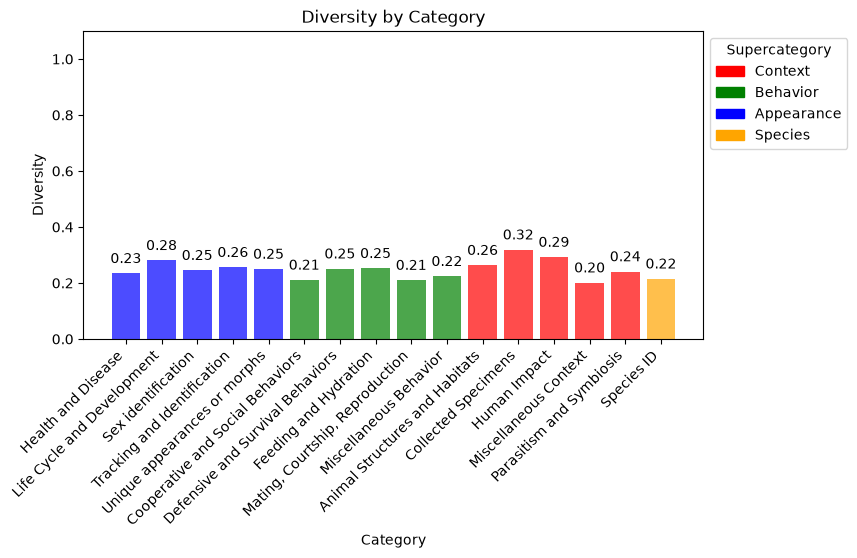

In [20]:
# Create the plot
fig, ax = plt.subplots(figsize=(8, 4))

# Create bars with colors based on supercategory
bars = ax.bar(x, category_metrics['diversity'], color=colors, alpha=0.7)

ax.set_ylabel("Diversity")
ax.set_xlabel("Category")
ax.set_title("Diversity by Category")
ax.set_ylim(0, 1.1)  # Extend limit to prevent overlap with title

# Set x-ticks
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

# Add legend
handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in supercategory_colors.values()]
ax.legend(handles, supercategory_colors.keys(), title="Supercategory", loc="upper left", bbox_to_anchor=(1, 1))

plt.show()

### NDCG

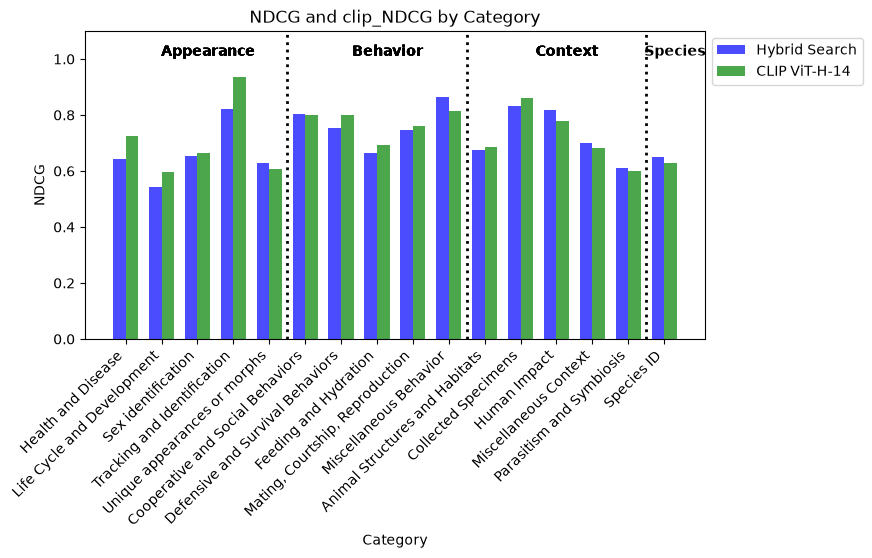

In [21]:
fig, ax = plt.subplots(figsize=(8, 4))

# Create side-by-side bars for NDCG and clip_NDCG
bars1 = ax.bar(x - bar_width/2, category_metrics['NDCG'], width=bar_width,
               label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, category_metrics['clip_NDCG'], width=bar_width,
               label="CLIP ViT-H-14", color="green", alpha=0.7)

# Set x-ticks and category labels
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")

# add labels and titles
ax.set_ylabel("NDCG")
ax.set_xlabel("Category")
ax.set_title("NDCG and clip_NDCG by Category")
ax.set_ylim(0, 1.1)  # Increase top limit to make room for supercategory labels
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))

# Add dotted vertical lines between supercategory groups
supercats = category_metrics['supercategory'].values
for i in range(1, len(supercats)):
    if supercats[i] != supercats[i-1]:
        # Place line halfway between bars at index i-0.5
        ax.axvline(x=i - 0.5, color='black', linestyle=':', linewidth=2)

# Add supercategory labels above the groups
for supercat in category_metrics['supercategory']:
    # Find indices for current supercategory
    indices = np.where(category_metrics['supercategory'] == supercat)[0]
    # Calculate the center position for the group
    center_x = ((indices[0] + indices[-1]) / 2) + 0.3
    # Add the supercategory label above the bars
    ax.text(center_x, 1.0, supercat, ha='center', va='bottom',
            fontsize=10, fontweight='bold')

plt.show()

### MRR

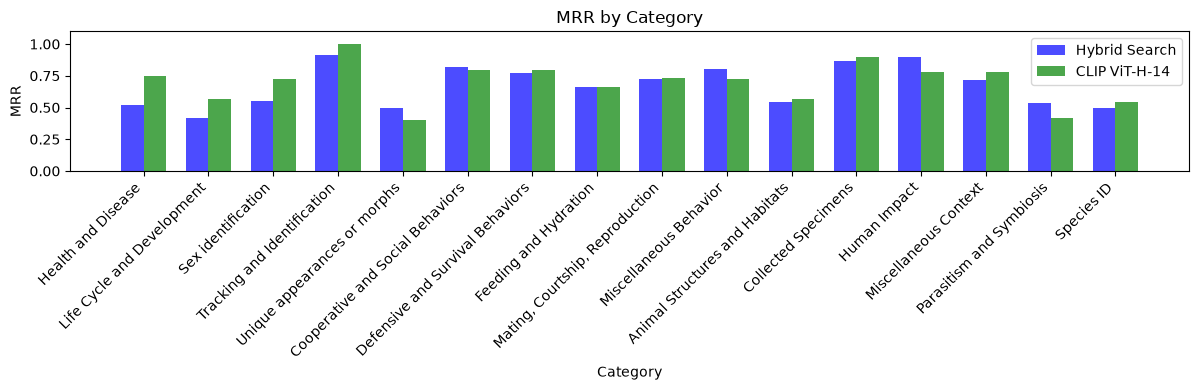

In [22]:
# MRR and clip_MRR by Category
fig, ax = plt.subplots(figsize=(12, 4))
bar_width = 0.35
x = np.arange(len(category_metrics['category']))
bars1 = ax.bar(x - bar_width/2, category_metrics['rr'], width=bar_width, label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, category_metrics['clip_rr'], width=bar_width, label="CLIP ViT-H-14", color="green", alpha=0.7)
ax.set_ylabel("MRR")
ax.set_xlabel("Category")
ax.set_title("MRR by Category")
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(category_metrics['category'], rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

## Metrics based on Iconic Group

In [23]:
# Group by iconic_group and calculate the sum/mean of each metric
iconic_metrics = df.groupby(['iconic_group']).agg({
    'total_images': 'sum',
    'correctly_returned': 'sum',
    'incorrectly_returned': 'sum',
    'relevant_images': 'sum',
    'non_relevant_images': 'sum',
    'accuracy': 'mean',
    'precision': 'mean',
    'recall': 'mean',
    'hit': 'mean',
    'NDCG': 'mean',
    'clip_NDCG': 'mean',
    'rr': 'mean',
    'clip_rr': 'mean',
    'diversity': 'mean'
}).reset_index()

iconic_metrics

,iconic_group,total_images,correctly_returned,incorrectly_returned,relevant_images,non_relevant_images,accuracy,precision,recall,hit,NDCG,clip_NDCG,rr,clip_rr,diversity
0,Amphibians,200,167,33,37,163,0.835000,0.185000,0.715326,1.000000,0.583145,0.610064,0.392361,0.494048,0.228122
1,Animalia,150,116,34,20,130,0.773333,0.133333,0.505051,0.666667,0.594191,0.615310,0.429487,0.547619,0.235546
2,Arachnids,350,274,76,51,299,0.782857,0.145714,0.568481,0.857143,0.529539,0.627987,0.374276,0.678571,0.222813
3,Birds,2000,1533,467,435,1565,0.766500,0.217500,0.647245,0.975000,0.704544,0.751689,0.681495,0.787295,0.268365
4,Combo,50,49,1,24,26,0.980000,0.480000,0.857143,1.000000,0.953060,0.968824,1.000000,1.000000,0.212190
5,Fish,350,281,69,76,274,0.802857,0.217143,0.509894,0.857143,0.675897,0.649654,0.688776,0.518398,0.216921
6,Fungi,300,241,59,86,214,0.803333,0.286667,0.545513,1.000000,0.763133,0.737553,0.777778,0.805556,0.206352
7,Insects,1250,745,505,168,1082,0.596000,0.134400,0.450800,0.880000,0.581010,0.621283,0.458840,0.554834,0.254939
8,Mammals,2400,1902,498,652,1748,0.792500,0.271667,0.690460,0.979167,0.810359,0.797148,0.845486,0.760488,0.236754
9,Mollusks,200,116,84,34,166,0.580000,0.170000,0.285183,1.000000,0.683657,0.651356,0.637500,0.458333,0.259512


In [24]:
# Bar width
bar_width = 0.35
x = np.arange(len(iconic_metrics['iconic_group']))

### Accuracy

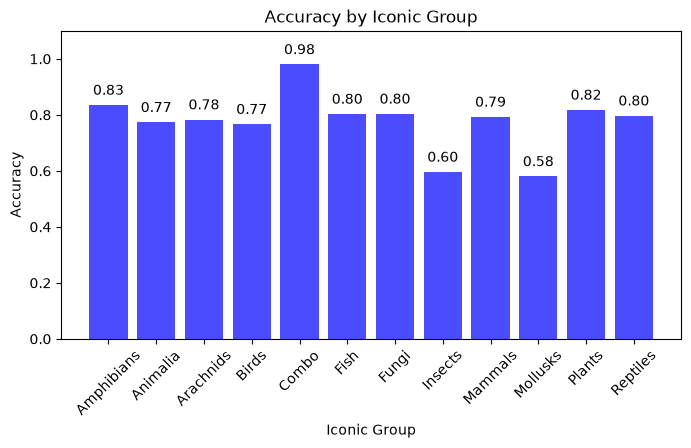

In [25]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(iconic_metrics['iconic_group'], iconic_metrics['accuracy'], color="blue", alpha=0.7)

ax.set_ylabel("Accuracy")
ax.set_xlabel("Iconic Group")
ax.set_title("Accuracy by Iconic Group")
ax.set_ylim(0, 1.1)  # Accuracy is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Precision

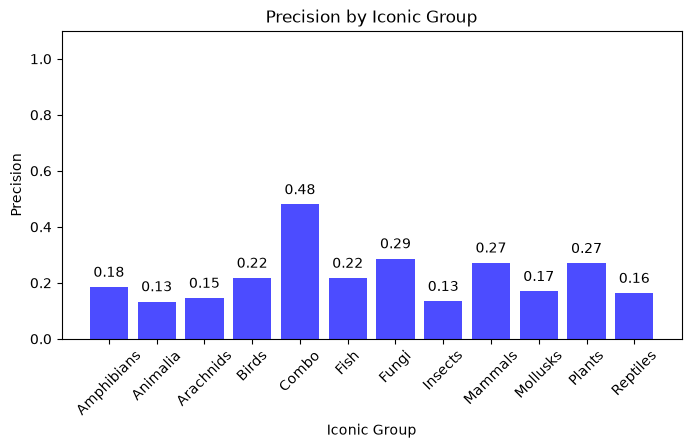

In [26]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(iconic_metrics['iconic_group'], iconic_metrics['precision'], color="blue", alpha=0.7)

ax.set_ylabel("Precision")
ax.set_xlabel("Iconic Group")
ax.set_title("Precision by Iconic Group")
ax.set_ylim(0, 1.1)  # Precision is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Recall

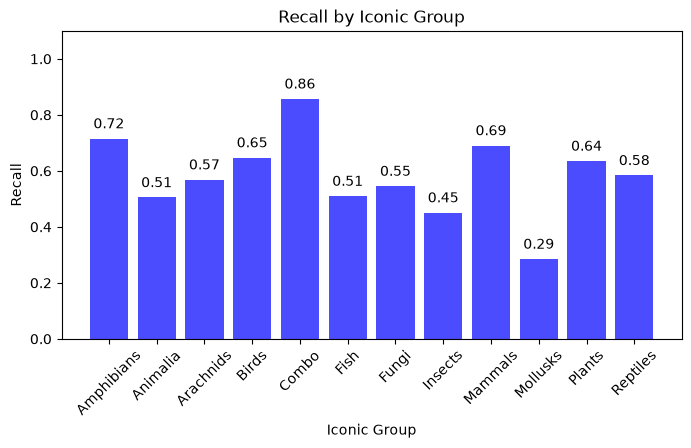

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.bar(iconic_metrics['iconic_group'], iconic_metrics['recall'], color="blue", alpha=0.7)

ax.set_ylabel("Recall")
ax.set_xlabel("Iconic Group")
ax.set_title("Recall by Iconic Group")
ax.set_ylim(0, 1.1)  # recall is between 0 and 1

# Add labels directly on bars
ax.bar_label(bars, fmt="%.2f", padding=5)

plt.xticks(rotation=45)
plt.show()

### Hit Rate

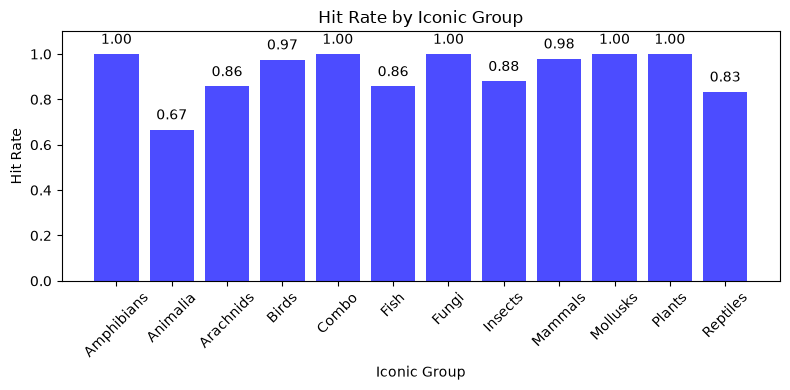

In [28]:
# Hit Rate by Iconic Group
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(iconic_metrics['iconic_group'], iconic_metrics['hit'], color="blue", alpha=0.7)
ax.set_ylabel("Hit Rate")
ax.set_xlabel("Iconic Group")
ax.set_title("Hit Rate by Iconic Group")
ax.set_ylim(0, 1.1)
ax.bar_label(bars, fmt="%.2f", padding=5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Diversity


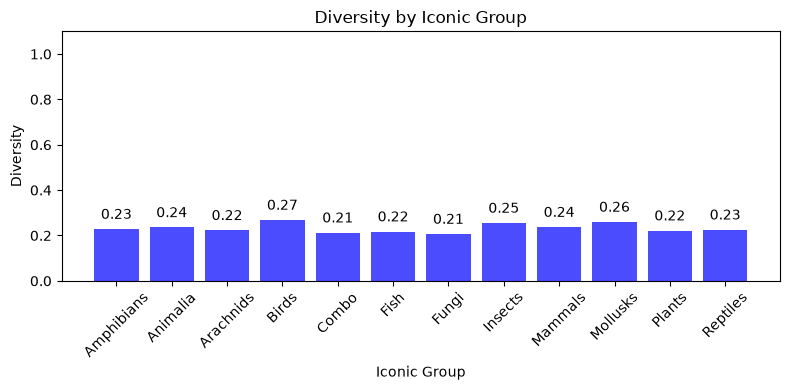

In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(iconic_metrics['iconic_group'], iconic_metrics['diversity'], color="blue", alpha=0.7)
ax.set_ylabel("Diversity")
ax.set_xlabel("Iconic Group")
ax.set_title("Diversity by Iconic Group")
ax.set_ylim(0, 1.1)
ax.bar_label(bars, fmt="%.2f", padding=5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### NDCG

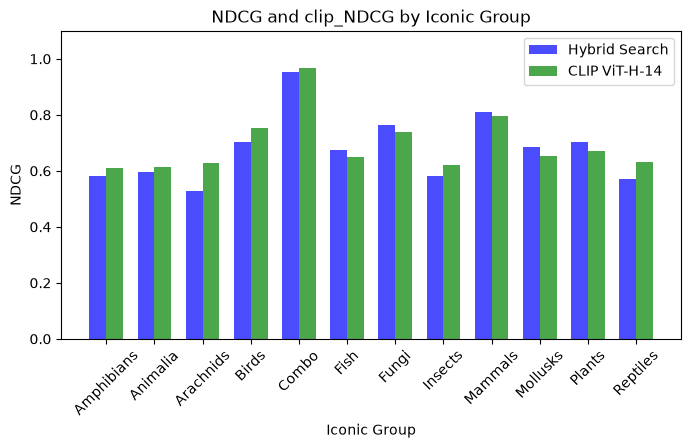

In [30]:
# Creating the plot with both NDCG and clip_NDCG
fig, ax = plt.subplots(figsize=(8, 4))

# Bar width
bar_width = 0.35
x = np.arange(len(iconic_metrics['iconic_group']))

# Bars for NDCG and clip_NDCG
bars1 = ax.bar(x - bar_width/2, iconic_metrics['NDCG'], width=bar_width, label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, iconic_metrics['clip_NDCG'], width=bar_width, label="CLIP ViT-H-14", color="green", alpha=0.7)

# Labels and title
ax.set_ylabel("NDCG")
ax.set_xlabel("Iconic Group")
ax.set_title("NDCG and clip_NDCG by Iconic Group")
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(iconic_metrics['iconic_group'], rotation=45)
ax.legend()

# Show plot
plt.show()

### MRR

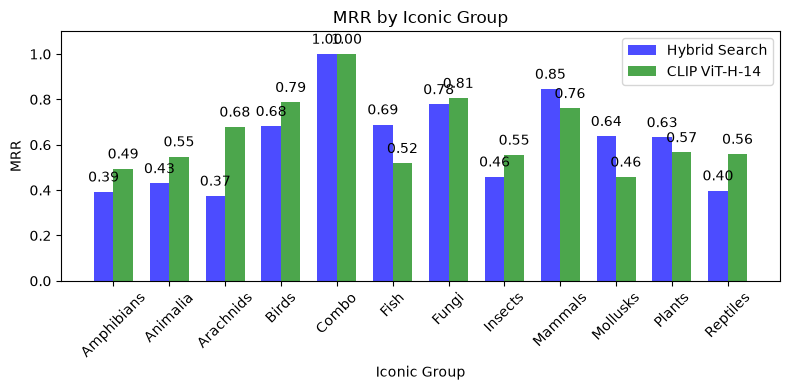

In [31]:
# MRR and clip_MRR by Iconic Group
fig, ax = plt.subplots(figsize=(8, 4))
bar_width = 0.35
x = np.arange(len(iconic_metrics['iconic_group']))
bars1 = ax.bar(x - bar_width/2, iconic_metrics['rr'], width=bar_width, label="Hybrid Search", color="blue", alpha=0.7)
bars2 = ax.bar(x + bar_width/2, iconic_metrics['clip_rr'], width=bar_width, label="CLIP ViT-H-14", color="green", alpha=0.7)
ax.set_ylabel("MRR")
ax.set_xlabel("Iconic Group")
ax.set_title("MRR by Iconic Group")
ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(iconic_metrics['iconic_group'], rotation=45)
ax.legend()
ax.bar_label(bars1, fmt="%.2f", padding=5)
ax.bar_label(bars2, fmt="%.2f", padding=5)
plt.tight_layout()
plt.show()

## Displaying Metrics used in Leaderboard

Here we will show the metrics used in [INQUIRE's leaderboard](https://inquire-benchmark.github.io/) to be able to see how our Hybrid Search is doing when compared to their leaderboard.

In [32]:
ldboard = {
    "Method": "Hybrid Search",
    "Overall": overall_metrics['precision'],
    "Appearance": supercategory_metrics[supercategory_metrics['supercategory']== 'Appearance']['precision'][0],
    "Behavior": supercategory_metrics[supercategory_metrics['supercategory']== 'Behavior']['precision'][1],
    "Context": supercategory_metrics[supercategory_metrics['supercategory']== 'Context']['precision'][2],
    "Species": supercategory_metrics[supercategory_metrics['supercategory']== 'Species']['precision'][3]

}
# Convert the dictionary to a DataFrame
ldboard_df = pd.DataFrame([ldboard])
ldboard_df

,Method,Overall,Appearance,Behavior,Context,Species
0,Hybrid Search,0.21925,0.172308,0.241356,0.24186,0.246667


## Comparing v15 to v14 and v12

## Insights & Conclusion

**System Difference**

* **v12:** Weaviate hybrid search over **one fused CLIP index** (caption + image embeddings combined into a single `clip` vector), with the Weaviate / [ms-marco-MiniLM-L6-v2](https://huggingface.co/cross-encoder/ms-marco-MiniLM-L6-v2) reranker. CLIP inference had **no Triton dynamic batching**.
* **v14:**
  * introduced in v13:
    * **Weaviate → Milvus** as the vector database.
    * **Weaviate reranker → Apple CLIP DFN** (`DFN5B-CLIP-ViT-H-14-378`): query text vs stored `image_vector`s.
    * **One fused index → dual indexing**: separate `caption_vector` and `image_vector` fields, blended at query time (`clip_alpha=0.7`).
    * **No Triton batching → Triton dynamic batching** for CLIP (and Gemma when served on Triton), so concurrent embedding/caption requests coalesce into larger GPU batches.
  * v13 additions plus LLM Image Byte Limiting - Caption images are preprocessed before NRP gemma calls: RGB conversion, longest-side cap (`LLM_MAX_IMAGE_SIDE=6144`), and JPEG downscale/quality stepping to stay under `LLM_MAX_IMAGE_BYTES` (12 MiB).
* **v15:**
  * **Two-caption prompt** (`scientific_two_captions_v1`): Gemma emits `long_caption`, `short_caption` (≤55 tokens, visible content only), and 15 `keywords`.
  * **CLIP vs BM25 text split**: `caption_vector` embeds **`short_caption` + `keywords`** in one 77-token CLIP pass (keywords used to fall past the truncation cutoff). BM25 `search_text` still indexes **`long_caption` + keywords**.
  * **Schema**: `long_caption` and `short_caption` stored as separate VARCHAR fields (replacing a single `caption` column).
  * Hybrid weights unchanged (`query_alpha=0.4`, `clip_alpha=0.7`). CLIP DFN still reranks on `image_vector`.
* **v16:**
  * **Query-only** (`SKIP_INDEX=true`): reuse the v15 collections. No recaption and no collection drop. The only IR change is hybrid blend weights at query time.
  * **Blend sweep A–H** on `query_alpha` / `clip_alpha`. Production pick **H**: `query_alpha=0.65`, `clip_alpha=0.7` → **46% image / 20% caption / 35% BM25** (v15 was **28 / 12 / 60**).
  * `clip_alpha` did not move hit sets at `query_alpha≤0.6` (A/C vs v15; F vs B). Sage hit collapses between 0.65 and 0.70 — **E fails the v15 Sage floor**.

---

**Overall Metrics Comparison**

v16 is skip-index blend **H** (`query_alpha=0.65`, `clip_alpha=0.7`) on the v15 INQUIRE collection. **Δ (v16 − v15)** is the blend-only increment. v12 is the Weaviate fused-index reference. Hit = Success@50.

| Metric                   | v12 | v15 | v16 | Δ (v16 − v15) |
| ------------------------ | --- | --- | --- | ------------- |
| **Total Images**         | 8,000 | 8,000 | 8,000 | 0 |
| **Correctly Returned**   | 6,855 | 4,793 | 6,018 | +1,225 |
| **Incorrectly Returned** | 1,145 | 3,207 | 1,982 | −1,225 |
| **Relevant Images**      | 1,876 | 1,324 | 1,754 | +430 |
| **Accuracy**             | 0.8569 | 0.5991 | 0.7523 | +0.1532 |
| **Precision**            | 0.2345 | 0.1655 | 0.2193 | +0.0538 |
| **Recall**               | 0.6437 | 0.4433 | 0.6042 | +0.1609 |
| **Hit Rate**             | 0.9375 | 0.8438 | 0.9437 | +0.0999 |
| **Diversity**            | 0.2179 | 0.2762 | 0.2447 | −0.0315 |
| **NDCG**                 | 0.6618 | 0.6827 | 0.7025 | +0.0198 |
| **clip_NDCG**            | 0.7111 | 0.7031 | 0.7199 | +0.0168 |
| **MRR**                  | 0.5932 | 0.6316 | 0.6642 | +0.0326 |
| **clip_MRR**             | 0.6805 | 0.6607 | 0.6901 | +0.0294 |
| **DLQ entries**          | — | 0 | 0 | 0 |

**Alpha sweep (hit / hybrid MRR).** Hit = Success@50. MRR = `rerank_score_reciprocal_rank`.

| Point | Folder | query_alpha | clip_alpha | weights (img / cap / BM25) | Hit | MRR |
| ----- | ------ | ----------- | ---------- | -------------------------- | --- | --- |
| v15 | *(v15 index)* | 0.40 | 0.7 | 28 / 12 / 60 | 84.4% | 0.632 |
| A | `v16_qa04_ca085` | 0.40 | 0.85 | 34 / 6 / 60 | 84.4% | 0.632 |
| C | `v16_qa04_ca05` | 0.40 | 0.50 | 20 / 20 / 60 | 84.4% | 0.632 |
| D | `v16_qa05_ca07` | 0.50 | 0.7 | 35 / 15 / 50 | 84.4% | 0.632 |
| B | `v16_qa06_ca07` | 0.60 | 0.7 | 42 / 18 / 40 | 93.1% | 0.656 |
| F | `v16_qa06_ca085` | 0.60 | 0.85 | 51 / 9 / 40 | 93.1% | 0.661 |
| **H (v16)** | **`v16_qa065_ca07`** | **0.65** | **0.7** | **46 / 20 / 35** | **94.4%** | **0.664** |
| E | `v16_qa07_ca07` | 0.70 | 0.7 | 49 / 21 / 30 | 97.5% | 0.635 |

**Why each `v16_qa*` batch was run.** Folder names encode the knobs (`qa` = `query_alpha`, `ca` = `clip_alpha`). Hybrid weights are `WeightedRanker(query_alpha × clip_alpha, query_alpha × (1 − clip_alpha), 1 − query_alpha)` → image / caption / BM25. All seven jobs are **skip-index** on the v15 collections (no recaption). They were launched in three waves so later jobs could condition on earlier ones.

- **Wave 1 — which knob moves anything?**
  - **A / `v16_qa04_ca085`:** hold `query_alpha=0.4` (v15), raise `clip_alpha` 0.7 → 0.85 (more image, less caption). Test whether the dense image/caption split matters while BM25 is still 60%. **This bench:** No-op vs v15 (84.4% / 0.632). `clip_alpha` dead while BM25 is 60%.
  - **C / `v16_qa04_ca05`:** hold `query_alpha=0.4`, lower `clip_alpha` 0.7 → 0.5 (more caption). Same question, other direction. **This bench:** No-op vs v15 (84.4% / 0.632). Same lock as A.
  - **B / `v16_qa06_ca07`:** hold `clip_alpha=0.7`, raise `query_alpha` 0.4 → 0.6 (BM25 60% → 40%). Test whether the dense vs BM25 mix is the lever. **This bench:** Unlock: 84.4% → 93.1%, MRR 0.632 → 0.656. Insect/species-ID queries re-enter k=50.
- **Wave 2 — where is the unlock / cliff, and is `clip_alpha` alive once BM25 drops?**
  - **D / `v16_qa05_ca07`:** `query_alpha=0.5`, `clip_alpha=0.7`. Interpolate v15 and B to find where the BM25 lock breaks. **This bench:** No-op vs v15 (84.4% / 0.632). Unlock is at 0.60, not 0.50.
  - **E / `v16_qa07_ca07`:** `query_alpha=0.7`, `clip_alpha=0.7`. Push past B: is more dense still worth it, or do Sage/Cloud fall off? **This bench:** 97.5% / 0.635 — more hits, worse MRR vs H. Rejected: Sage fails at 0.70.
  - **F / `v16_qa06_ca085`:** `query_alpha=0.6`, `clip_alpha=0.85`. Retest `clip_alpha` now that BM25 is 40% and no longer locking. **This bench:** Same hit as B (93.1%), MRR 0.661. `clip_alpha` still a no-op.
- **Wave 3 — sit between the unlock and the cliff.**
  - **H / `v16_qa065_ca07`:** `query_alpha=0.65`, `clip_alpha=0.7`. Between B (first unlock, Sage holds) and E (Sage fails). Keep INQUIRE's extra queries without crossing the cliff. Copied to `results/v16/` as the production pick. **This bench:** Only point that beats B: 94.4% / 0.664 (+2 queries: cross orbweaver, Red-capped Plover). Why H wins.


---

**Interpretation**

**Isolate v16 vs v15.** Same two-caption ingest, same dual-index, same CLIP DFN rerank. No recaption. Raising dense weight reopens the insect/species-ID hole that v13/v15 left out of k=50. DLQ stays **0**.

**H is the only sweep point that beats B.** Hit **84.4% → 94.4%** (135/160 → 151/160): **16 gained / 0 lost**. That is **+2 queries vs B (93.1%)** — cross orbweaver (Species ID) and Red-capped Plover broken-wing display. Accuracy **59.9% → 75.2%** (v12 85.7%). Production **MRR 0.63 → 0.66**. **E 97.5% fails Sage.**

---

**Insights**

- **This is the candidate-generation fix v15 asked for.** v15 said next IR work was more caption/BM25-vs-wait, more *dense* weight so insect and life-stage queries re-enter the top-50. H does that without recaption.
- **H uniquely earns its keep on INQUIRE.** Other benches have H = B on the hit set. Here 0.65 picks up two extra labeled queries vs 0.60. That is why H wins the composite vs B.
- **E's extra coverage is real and rejected.** 97.5% hit / 0.63 MRR (MRR actually *drops* vs H). Sage hit fails the v15 floor at 0.70.
- **A/C/D are no-ops vs v15.** Unlock is at 0.60; the last two queries unlock at 0.65. `clip_alpha` does not move this bench in the tested band.
- **Sex ID and life-cycle recover; unique morphs do not fully.** Sex identification **0.63 → 1.00**. Life cycle **0.67 → 0.87**. Unique appearances stay **0.78**. The remaining gap to v12 accuracy is still CLIP-image rerank vs MiniLM-on-caption, not this blend.

---

**Conclusion**

On INQUIRE, **v16 H is the coverage recovery on the v15 index** (hit **84.4% → 94.4%**, +16 / 0 vs v15, **+2 queries vs B**). H is the only sweep point that beats B. E 97.5% fails Sage. Keep H. Keep the two-caption prompt, and do not take E
